In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import numpy as np
from tqdm.auto import tqdm
from PIL import Image
import seaborn as sns
from sklearn.metrics import roc_curve, auc

In [3]:
# Define image parameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 16
NUM_EPOCHS = 35
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Create directories for saving models and plots
save_dir = 'model_checkpoints'
plot_dir = 'plots'
for directory in [save_dir, plot_dir]:
    if not os.path.exists(directory):
        os.makedirs(directory)

In [4]:
# Define transforms for data augmentation
train_transform = transforms.Compose([
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    transforms.RandomRotation(30),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2),
    transforms.RandomAffine(0, translate=(0.2, 0.2), scale=(0.8, 1.2)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [5]:
class ResNetClassifier(nn.Module):
    def __init__(self, num_classes=3):
        super(ResNetClassifier, self).__init__()
        # Change 1: Initialize without pre-trained weights
        self.resnet = models.resnet18(weights='IMAGENET1K_V1')  # changed from resnet50

        self.resnet.fc = nn.Sequential(
            nn.Linear(512, 256),      # changed from 2048 → 512 input
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)  # simplified, one less layer
        )

    def forward(self, x):
        return self.resnet(x)

In [6]:
# Cell [4] - Add class mapping print
# Check and load dataset
dataset_path = './COVID-19_Radiography_Dataset'
if not os.path.exists(dataset_path):
    raise ValueError(f"Dataset path {dataset_path} does not exist!")

dataset = datasets.ImageFolder(dataset_path, transform=train_transform)
if len(dataset) == 0:
    raise ValueError("No images found in the dataset directory")

# Print class mapping to verify classes
print("Class mapping:", dataset.class_to_idx)

# Rest of the cell remains the same
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = torch.utils.data.random_split(dataset, 
                                                         [train_size, val_size],
                                                         generator=generator)

# Change 7: Update data loaders with better settings
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=4,  # Increased workers
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)

Class mapping: {'covid': 0, 'normal': 1, 'pneumonia': 2}


In [7]:
model = ResNetClassifier().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    model.parameters(),
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=5,
    
)

In [8]:
# New Cell - Early Stopping Class
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0, verbose=True):
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.val_loss_min = float('inf')

    def __call__(self, val_loss, model, path='model_checkpoints/best_model_early_stop.pth'):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(val_loss, model, path)
        elif val_loss > self.best_loss + self.min_delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(val_loss, model, path)
            self.counter = 0

    def save_checkpoint(self, val_loss, model, path):
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model...')
        torch.save(model.state_dict(), path)
        self.val_loss_min = val_loss

Using device: cuda
Training samples: 12124
Validation samples: 3032

Starting training...


Epoch 1/50 - Learning Rate: 0.001000


Epoch 1/50:   0%|                    | 0/758 [00:00<?, ?it/s]

Training    - Loss: 0.5291 | Accuracy: 78.52%
Validation  - Loss: 0.4480 | Accuracy: 81.60%
Validation loss decreased (inf --> 0.448028). Saving model...
------------------------------------------------------------

Epoch 2/50 - Learning Rate: 0.001000


Epoch 2/50:   0%|                    | 0/758 [00:00<?, ?it/s]

Training    - Loss: 0.3994 | Accuracy: 85.83%
Validation  - Loss: 0.5462 | Accuracy: 83.51%
EarlyStopping counter: 1 out of 7
------------------------------------------------------------

Epoch 3/50 - Learning Rate: 0.001000


...

Training    - Loss: 0.0737 | Accuracy: 97.87%
Validation  - Loss: 0.0965 | Accuracy: 96.90%
EarlyStopping counter: 5 out of 7
------------------------------------------------------------

Epoch 36/50 - Learning Rate: 0.000100


Epoch 36/50:   0%|                    | 0/758 [00:00<?, ?it/s]

Training    - Loss: 0.0672 | Accuracy: 97.93%
Validation  - Loss: 0.1005 | Accuracy: 97.33%
Learning rate decreased to 0.000010
EarlyStopping counter: 6 out of 7
------------------------------------------------------------

Epoch 37/50 - Learning Rate: 0.000010


Epoch 37/50:   0%|                    | 0/758 [00:00<?, ?it/s]

Training    - Loss: 0.0718 | Accuracy: 97.83%
Validation  - Loss: 0.0973 | Accuracy: 97.53%
EarlyStopping counter: 7 out of 7

Early stopping triggered!

Training completed!


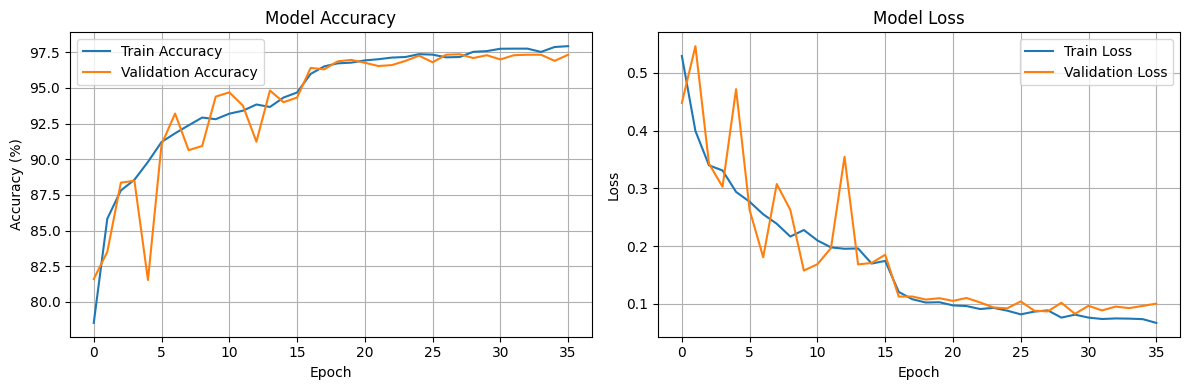

In [9]:
# Define training parameters
BATCH_SIZE = 32  # Increased from 16
NUM_EPOCHS = 50  # Increased from 35
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
from tqdm.notebook import tqdm

try:
    train_acc_history = []
    val_acc_history = []
    train_loss_history = []
    val_loss_history = []
    best_val_loss = float('inf')
    early_stopping = EarlyStopping(patience=7, verbose=True)

    model = model.to(DEVICE)
    print(f"Using device: {DEVICE}")
    print(f"Training samples: {len(train_loader.dataset)}")
    print(f"Validation samples: {len(val_loader.dataset)}")

    print("\nStarting training...\n")

    for epoch in range(NUM_EPOCHS):
        current_lr = optimizer.param_groups[0]['lr']
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS} - Learning Rate: {current_lr:.6f}")
        
        # Initialize epoch stats
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        epoch_pbar = tqdm(total=len(train_loader),
                         desc=f'Epoch {epoch+1}/{NUM_EPOCHS}',
                         bar_format='{l_bar}{bar:20}{r_bar}')
        
        model.train()
        for batch_idx, (inputs, labels) in enumerate(train_loader):
            try:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                
                optimizer.zero_grad()
                
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                loss.backward()
                
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                
                optimizer.step()
                
                train_loss += loss.item()
                _, predicted = outputs.max(1)
                train_total += labels.size(0)
                train_correct += predicted.eq(labels).sum().item()
                
                current_train_acc = 100. * train_correct / train_total
                current_train_loss = train_loss / (batch_idx + 1)
                
                epoch_pbar.set_postfix({
                    'Loss': f'{current_train_loss:.4f}',
                    'Train Acc': f'{current_train_acc:.2f}%'
                })
                epoch_pbar.update(1)
                
            except Exception as e:
                print(f"\nError in training batch {batch_idx}: {e}")
                continue
        
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for val_inputs, val_labels in val_loader:
                val_inputs, val_labels = val_inputs.to(DEVICE), val_labels.to(DEVICE)
                val_outputs = model(val_inputs)
                val_loss += criterion(val_outputs, val_labels).item()
                _, val_predicted = val_outputs.max(1)
                val_total += val_labels.size(0)
                val_correct += val_predicted.eq(val_labels).sum().item()
    
        train_loss = train_loss / len(train_loader)
        train_acc = 100. * train_correct / train_total
        val_loss = val_loss / len(val_loader)
        val_acc = 100. * val_correct / val_total
    
        epoch_pbar.close()
    
        print(f'Training    - Loss: {train_loss:.4f} | Accuracy: {train_acc:.2f}%')
        print(f'Validation  - Loss: {val_loss:.4f} | Accuracy: {val_acc:.2f}%')
        
        scheduler.step(val_loss)
        
        if current_lr != optimizer.param_groups[0]['lr']:
            print(f'Learning rate decreased to {optimizer.param_groups[0]["lr"]:.6f}')
        
        early_stopping(val_loss, model)
        if early_stopping.early_stop:
            print("\nEarly stopping triggered!")
            break
        
        train_loss_history.append(train_loss)
        train_acc_history.append(train_acc)
        val_loss_history.append(val_loss)
        val_acc_history.append(val_acc)
        
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
        print('-' * 60)

    print("\nTraining completed!")

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(train_acc_history, label='Train Accuracy')
    plt.plot(val_acc_history, label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(train_loss_history, label='Train Loss')
    plt.plot(val_loss_history, label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"\nFatal error in training loop: {e}")
    raise

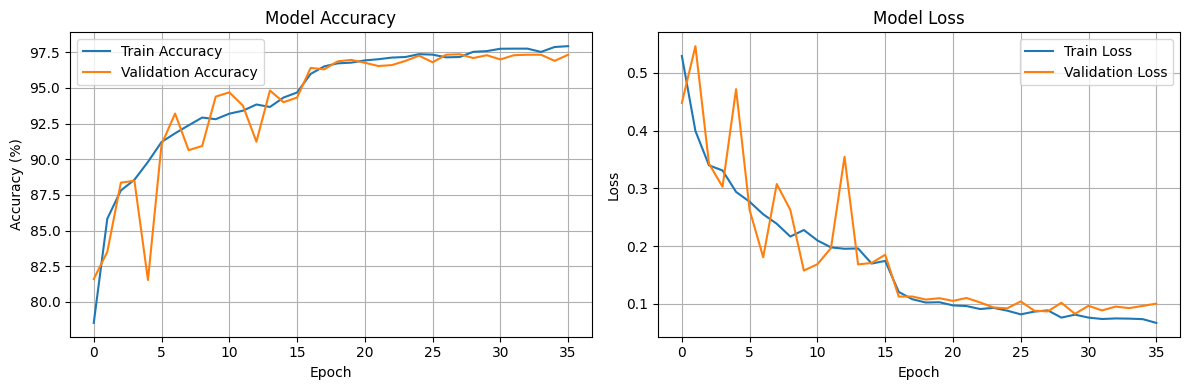

In [10]:
# Plot training history
plt.figure(figsize=(12, 4))

# Plot training and validation accuracy
plt.subplot(1, 2, 1)
plt.plot(train_acc_history, label='Train Accuracy')
plt.plot(val_acc_history, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history, label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Model Evaluation:


Evaluating:   0%|          | 0/190 [00:00<?, ?it/s]


Classification Report:
              precision    recall  f1-score   support

       covid       0.96      0.94      0.95       718
      normal       0.98      0.98      0.98      2034
   pneumonia       0.96      0.96      0.96       280

    accuracy                           0.97      3032
   macro avg       0.97      0.96      0.96      3032
weighted avg       0.97      0.97      0.97      3032



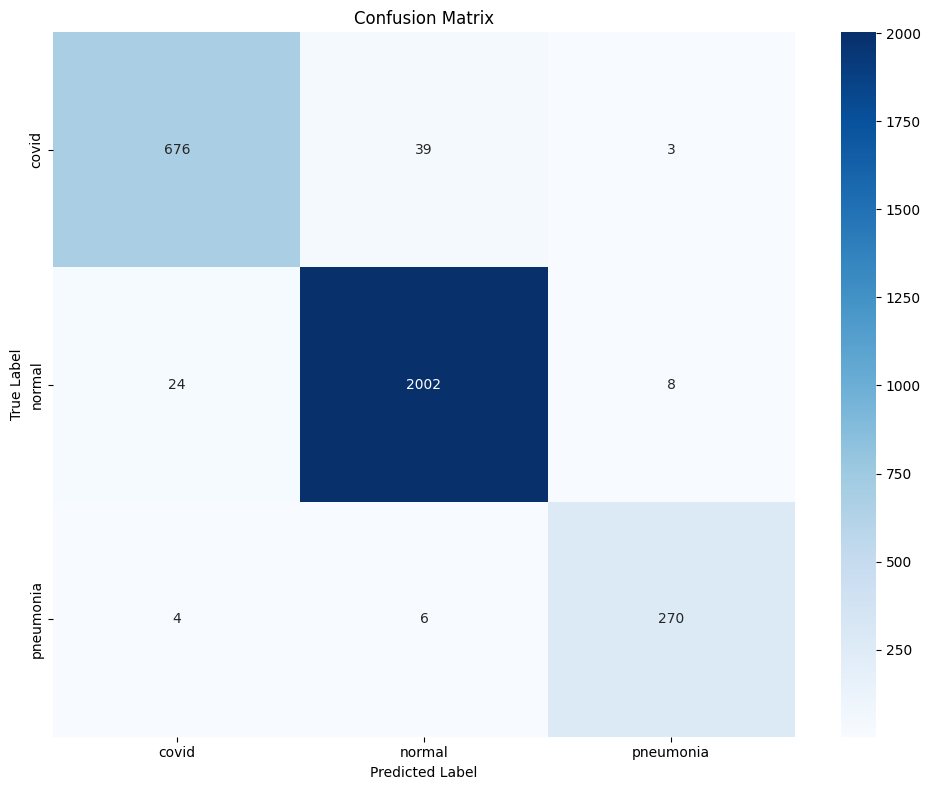


Detailed Metrics:


Calculating metrics:   0%|          | 0/190 [00:00<?, ?it/s]

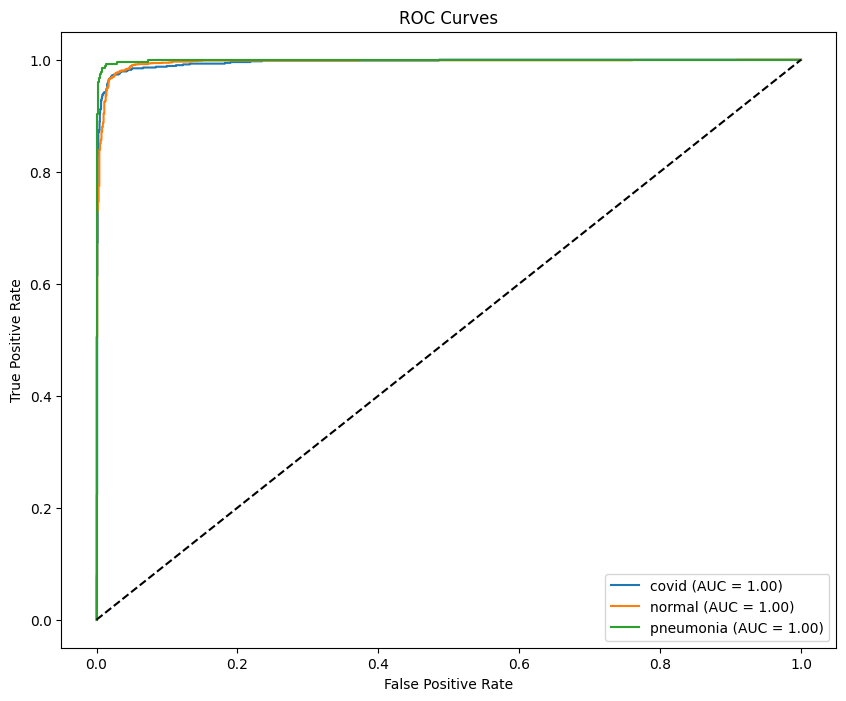

In [11]:
# Model evaluation functions
def evaluate_model(model, loader):
    """
    Evaluate the model on the given loader and print classification report
    """
    model.eval()
    all_preds = []
    all_labels = []
    
    # Progress bar for evaluation
    eval_bar = tqdm(total=len(loader), desc='Evaluating')
    
    with torch.no_grad():
        for inputs, labels in loader:
            try:
                # Move inputs to device
                inputs = inputs.to(DEVICE)
                
                # Forward pass
                outputs = model(inputs)
                _, predicted = outputs.max(1)
                
                # Store predictions and labels
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.numpy())
                
                eval_bar.update(1)
                
            except Exception as e:
                print(f"Error in evaluation batch: {e}")
                continue
    
    eval_bar.close()
    
    try:
        # Print classification report
        print("\nClassification Report:")
        print(classification_report(all_labels, all_preds, target_names=dataset.classes))
        
        # Calculate confusion matrix
        from sklearn.metrics import confusion_matrix
        import seaborn as sns
        
        cm = confusion_matrix(all_labels, all_preds)
        
        # Plot confusion matrix
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=dataset.classes,
                   yticklabels=dataset.classes)
        plt.title('Confusion Matrix')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Error generating evaluation metrics: {e}")


def evaluate_model_metrics(model, loader):
    """
    Calculate detailed metrics for model evaluation
    """
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc='Calculating metrics'):
            try:
                inputs = inputs.to(DEVICE)
                outputs = model(inputs)
                probabilities = torch.nn.functional.softmax(outputs, dim=1)
                _, predicted = outputs.max(1)
                
                all_probs.extend(probabilities.cpu().numpy())
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.numpy())
                
            except Exception as e:
                print(f"Error in metric calculation: {e}")
                continue
    
    try:
        from sklearn.metrics import roc_curve, auc
        
        # Convert to numpy arrays
        all_probs = np.array(all_probs)
        all_labels = np.array(all_labels)
        
        # Plot ROC curves
        plt.figure(figsize=(10, 8))
        for i, class_name in enumerate(dataset.classes):
            fpr, tpr, _ = roc_curve(all_labels == i, all_probs[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.2f})')
        
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curves')
        plt.legend(loc='lower right')
        plt.show()
        
    except Exception as e:
        print(f"Error plotting ROC curves: {e}")

# Example usage in Jupyter notebook:
# Evaluate the model
print("Model Evaluation:")
evaluate_model(model, val_loader)

# Calculate detailed metrics
print("\nDetailed Metrics:")
evaluate_model_metrics(model, val_loader)

# Example of single image prediction
# predict_image('path/to/your/image.jpg')

In [12]:
def predict_image(image_path):
    """
    Predict class for a single image
    """
    try:
        # Load and preprocess image
        image = Image.open(image_path).convert('RGB')  # Convert to RGB
        image_tensor = val_transform(image).unsqueeze(0).to(DEVICE)
        
        # Set model to evaluation mode
        model.eval()
        
        # Make prediction
        with torch.no_grad():
            output = model(image_tensor)
            probabilities = torch.nn.functional.softmax(output, dim=1)
            probability, predicted = torch.max(probabilities, 1)
            
            # Get prediction and probability
            predicted_class = dataset.classes[predicted.item()]
            confidence = probability.item()
            
            # Print results
            print(f"Predicted class: {predicted_class}")
            print(f"Confidence: {confidence:.2%}")
            
            # Show image with prediction
            plt.figure(figsize=(8, 6))
            plt.imshow(image)
            plt.title(f'Prediction: {predicted_class} ({confidence:.2%})')
            plt.axis('off')
            plt.show()
            
            return predicted_class, confidence
            
    except Exception as e:
        print(f"Error predicting image: {e}")
        return None, None

Evaluating:   0%|          | 0/190 [00:00<?, ?it/s]


Classification Report:
              precision    recall  f1-score   support

       covid       0.97      0.94      0.96       718
      normal       0.98      0.99      0.98      2034
   pneumonia       0.96      0.96      0.96       280

    accuracy                           0.98      3032
   macro avg       0.97      0.97      0.97      3032
weighted avg       0.98      0.98      0.98      3032



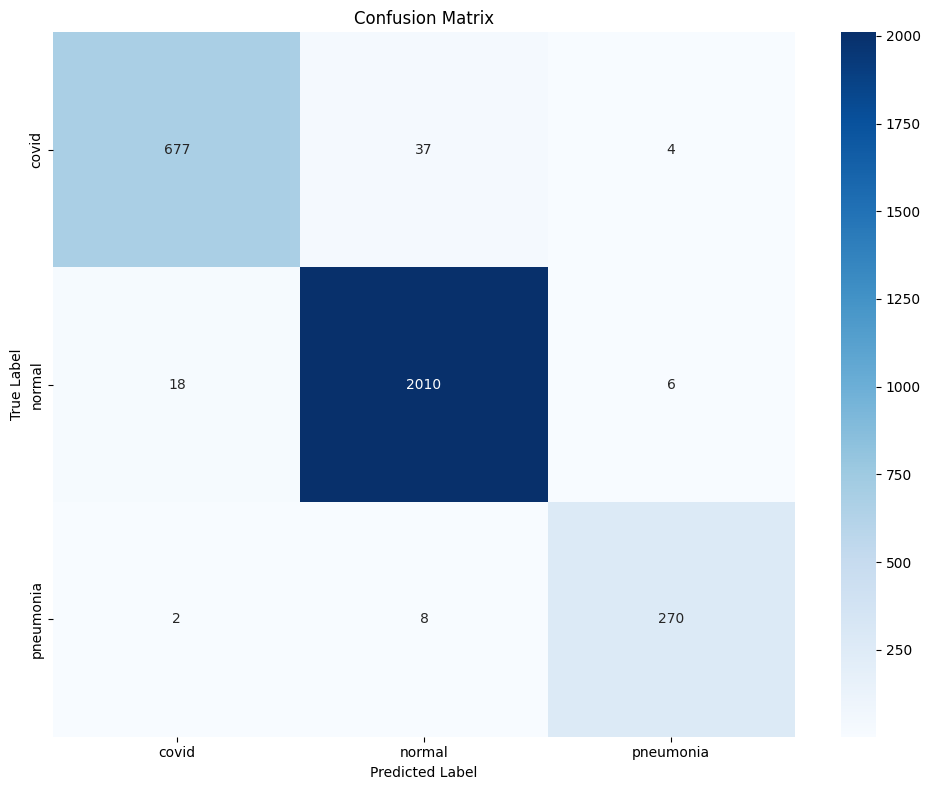

Calculating metrics:   0%|          | 0/190 [00:00<?, ?it/s]

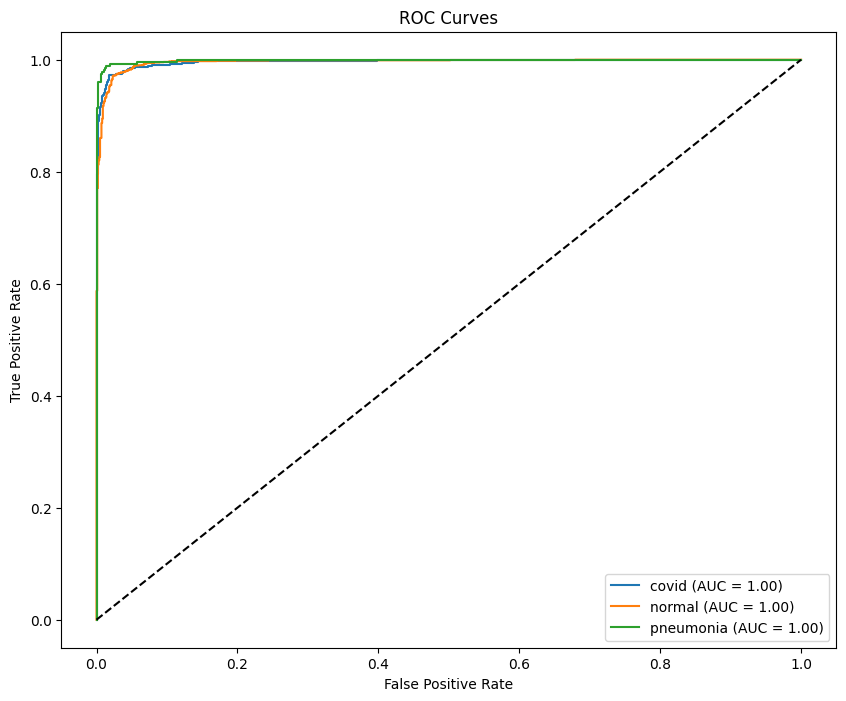

In [13]:
# For overall evaluation
evaluate_model(model, val_loader)

# For detailed metrics
evaluate_model_metrics(model, val_loader)


Predicted class: covid
Confidence: 99.97%


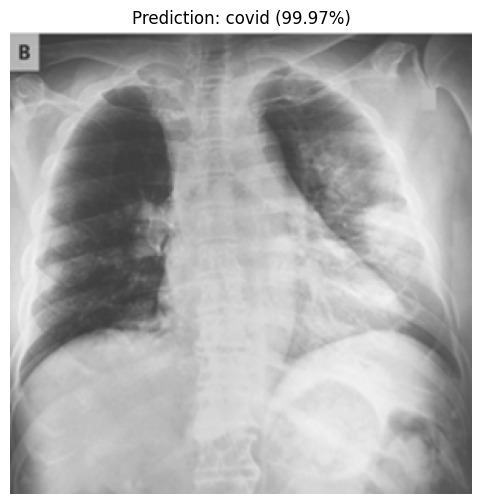

Predicted class: covid
Confidence: 100.00%


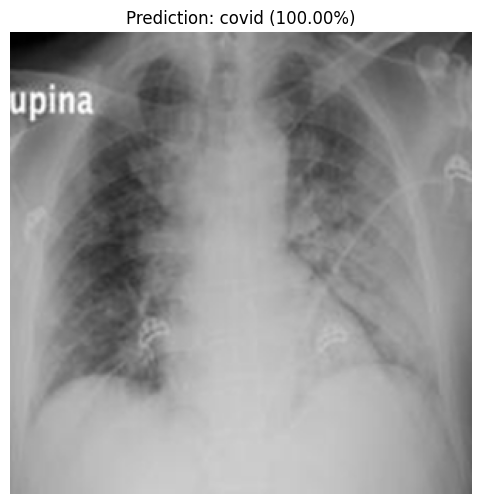

Error predicting image: [Errno 2] No such file or directory: 'COVID-19_Radiography_Dataset\\Lung_Opacity\\images\\Lung_Opacity-1.png'


(None, None)

In [14]:
# For single image prediction
predict_image('COVID-19_Radiography_Dataset/covid/images/COVID-5.png')
predict_image('COVID-19_Radiography_Dataset/covid/images/COVID-50.png')
predict_image('COVID-19_Radiography_Dataset\Lung_Opacity\images\Lung_Opacity-1.png')

To save the model

In [22]:
import h5py

In [23]:
def save_model_h5(model, save_path='model_checkpoints/covid_classifier_resnet.h5'):
    """
    Save the model as H5 file
    """
    try:
        # Create directory if it doesn't exist
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        
        # Save model
        torch.save(model.state_dict(), save_path)
        print(f"Model saved successfully to {save_path}")
        
    except Exception as e:
        print(f"Error saving model: {e}")

# Save the model
save_model_h5(model)

Model saved successfully to model_checkpoints/covid_classifier_resnet.h5


In [24]:
def load_model_h5(load_path='model_checkpoints/covid_classifier_resnet.h5'):
    """
    Load the model from H5 file
    """
    try:
        # Create new model instance
        model = ResNetClassifier()
        
        # Load weights
        model.load_state_dict(torch.load(load_path))
        model = model.to(DEVICE)
        
        print(f"Model loaded successfully from {load_path}")
        return model
            
    except Exception as e:
        print(f"Error loading model: {e}")
        return None

# To load the saved model:
# loaded_model = load_model_h5()